In [2]:
# Load Raw Dataset

rockyou_path = '/home/ayush_shekhar_chauhan/Desktop/Password-Strength-Analyser/ml/data/raw/rockyou.txt'

with open(rockyou_path, 'r', encoding='latin-1') as file:
    passwords = [line for line in file]


# Clean Dataset

passwords_clean = [line.rstrip('\n\r') for line in passwords]
passwords_clean = [password for password in passwords_clean if password != ""]


# Random Sampling

import random

random.seed(42)

sample_passwords = random.sample(passwords_clean, 150000)

print(len(sample_passwords))

# zxcvbn can't process data larger than 72 chars -> remove passwords more than 72 chars

sample_passwords = [password for password in sample_passwords if len(password) <= 72]

print(len(sample_passwords))


150000
149991


In [3]:
# Testing zxcvbn

from zxcvbn import zxcvbn

test_passwords = sample_passwords[:10]

for password in test_passwords :
    result = zxcvbn(password)

    print("Password:", password)
    print("Score:", result["score"])
    print("Guesses:", result["guesses"])
    print("Crack time:", result["crack_times_display"]["offline_slow_hashing_1e4_per_second"])
    print()




# Understanding -> Using Score as label isn't very much reliable we might use guesses as well

Password: Persian23
Score: 1
Guesses: 471000
Crack time: 47 seconds

Password: demetriusc
Score: 1
Guesses: 19922
Crack time: 2 seconds

Password: franciska
Score: 1
Guesses: 34600
Crack time: 3 seconds

Password: 411639213
Score: 2
Guesses: 27604000
Crack time: 46 minutes

Password: plopper11
Score: 3
Guesses: 156463000
Crack time: 4 hours

Password: ry2048
Score: 1
Guesses: 110000
Crack time: 11 seconds

Password: singh129
Score: 2
Guesses: 2210000
Crack time: 4 minutes

Password: 19dec28
Score: 2
Guesses: 10000001
Crack time: 17 minutes

Password: 4569882
Score: 1
Guesses: 740000
Crack time: 1 minute

Password: ilovederk
Score: 3
Guesses: 100830000
Crack time: 3 hours



In [4]:
# Converting Raw Data to pandas DataFrame 

import pandas as pd

temp_df = pd.DataFrame(sample_passwords, columns=["passwords"])

# Function To get SCORE and GUESSES

def get_zxcvbn_data (password) :
    result = zxcvbn(password)

    return result['score'], result['guesses']

zxcvbn_results = temp_df['passwords'].apply(get_zxcvbn_data)

zxcvbn_results = zxcvbn_results.apply(pd.Series)
zxcvbn_results.columns = ["score", "guesses"]

# Combining DataFrames 1 -> temp_df with Sample_passwords and 2 -> zxcvbn Results

df = pd.concat([temp_df, zxcvbn_results], axis=1)

print(df)

           passwords  score                        guesses
0          Persian23      1                         471000
1         demetriusc      1                          19922
2          franciska      1                          34600
3          411639213      2                       27604000
4          plopper11      3                      156463000
...              ...    ...                            ...
149986      lover802      1                         722000
149987  ???FUTURO158      4  10527668159.99999991429376678
149988    0914325910      3                      146010000
149989         fa333      1                          20000
149990       rover11      1                         188640

[149991 rows x 3 columns]


In [5]:
def assign_strength (score) :
    if score <= 1 :
        return "Weak"
    elif score <= 3 :
        return "Medium"
    else :
        return "Strong"

df["strength"] = df["score"].apply(assign_strength) 

In [6]:
# Adding more Strong Candidates to balance Classes 

import random
import secrets
import string

characters = (
    string.ascii_letters +
    string.digits +
    string.punctuation
)

def generate_random_passwords (lenght) :
    return "".join(secrets.choice(characters) for _ in range(lenght))

for _ in range(5) :
    print(generate_random_passwords(10))

+e<(oDO/h?
+M&x<(2dVB
fd*X7El/@h
[Us[W)@@s_
Cgr7dD6gC}


In [7]:
# Loading Words From Linux's pre-existing Dictionary

wordlist_path = '/home/ayush_shekhar_chauhan/Desktop/Password-Strength-Analyser/ml/data/raw/american-english'

with open (wordlist_path, "r", encoding="utf-8") as file :
    words = [word.strip().lower() for word in file]

words = [word for word in words if word.isalpha() and 4 <= len(word) <= 8]

words = list(set(words))

# Generating passphrase

def generate_passphrase (words_counts=4) :
    selected_words = random.sample(words, words_counts)
    return "-".join(selected_words)

random_candidates = [
    generate_random_passwords(random.randint(12, 20))
    for _ in range(15000)
]

passphrase_candidates = [
    generate_passphrase(random.randint(4, 6))
    for _ in range(15000)
]

strong_candidates = random_candidates + passphrase_candidates

print(len(random_candidates))
print(len(passphrase_candidates))
print(len(strong_candidates))

print(random_candidates[:5])
print(passphrase_candidates[:5])

15000
15000
30000
['y(-i3&GJkhG$>/f~hY}', 'aDGB,cS&))_!NV2uHbG', '3K+lWjL8wy/INe\\', '1|_Sr;?4&]kuG2"', 'R])`=j/RwUYg7/C++0|5']
['positron-furnish-payware-refunds-curlers-noumea', 'eviction-larousse-unmans-kibitzes', 'typify-outsizes-honester-burgle', 'geodesic-ruffling-mfume-brooches', 'snits-boeotia-allots-gruff']


In [8]:
# Adding Candidates to df

candidates_df = pd.DataFrame(
    strong_candidates, 
    columns=["passwords"]
)

candidates_results = candidates_df["passwords"].apply(get_zxcvbn_data)
candidates_results = candidates_results.apply(pd.Series)
candidates_results.columns = ["score", "guesses"]

candidates_df = pd.concat([candidates_df, candidates_results], axis=1)

candidates_df["strength"] = candidates_df["guesses"].apply(assign_strength)

print(candidates_df)

                                     passwords  score  \
0                          y(-i3&GJkhG$>/f~hY}      4   
1                          aDGB,cS&))_!NV2uHbG      4   
2                              3K+lWjL8wy/INe\      4   
3                              1|_Sr;?4&]kuG2"      4   
4                         R])`=j/RwUYg7/C++0|5      4   
...                                        ...    ...   
29995            pottage-hotheads-lucre-isidro      4   
29996  slut-baggage-arneb-aymara-trick-parnell      4   
29997     gladys-woollies-bizarre-flogs-nicole      4   
29998  upmarket-usurpers-symposia-lashes-dorky      4   
29999          stunted-braise-googles-wisteria      4   

                                 guesses strength  
0                   10000000000000000001   Strong  
1                   10000000000000000001   Strong  
2                       1000000000000001   Strong  
3                       1000000000000001   Strong  
4                  100000000000000000001   Strong  
...

In [9]:
final_df = pd.concat([df, candidates_df], ignore_index=True)

print(final_df["strength"].value_counts(normalize=True) * 100)
print(final_df["strength"].value_counts())

strength
Medium    47.737942
Weak      30.138174
Strong    22.123884
Name: proportion, dtype: float64
strength
Medium    85924
Weak      54246
Strong    39821
Name: count, dtype: int64


In [10]:
final_df.to_csv("../data/processed/password_dataset.csv", index=False)

In [15]:
# Feature Engineering

from collections import Counter

def extract_features(password):
    features = {}

    features["length"] = len(password)

    features["uppercase_count"] = sum(
        1 for ch in password if ch.isupper()
    )

    features["lowercase_count"] = sum(
        1 for ch in password if ch.islower()
    )

    features["digit_count"] = sum(
        1 for ch in password if ch.isdigit()
    )

    features["special_count"] = sum(
        1 for ch in password if not ch.isalnum()
    )

    features["unique_char_count"] = len(set(password))

    features["unique_char_ratio"] = (
        len(set(password)) / len(password)
    )

    frequency = Counter(password)
    features["max_char_frequency"] = (
        max(frequency.values())
    )

    features["has_sequential_pattern"] = has_sequential_pattern(password)

    features["has_keyboard_pattern"] = has_keyboard_pattern(password)

    return features


def has_sequential_pattern(password):
    ascending = 1
    descending = 1

    for i in range(1, len(password)):
        curr = ord(password[i])
        prev = ord(password[i - 1])

        if curr - prev == 1:
            ascending += 1
            descending = 1

        elif curr - prev == -1:
            descending += 1
            ascending = 1

        else:
            ascending = 1
            descending = 1

        if ascending >= 4 or descending >= 4:
            return 1

    return 0

def has_keyboard_pattern(password):
    patterns = [
        "qwerty",
        "asdfgh",
        "zxcvbn",
        "qwer",
        "asdf",
        "zxcv"
    ]

    lowercase_password = password.lower()

    for pattern in patterns:
        if pattern in lowercase_password:
            return 1

    return 0


feature_df = final_df["passwords"].apply(
    lambda password : pd.Series(extract_features(password))
)


In [ ]:
# Preparing Data to train models 

X = feature_df
y = final_df["strength"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

(179991, 10)
(179991,)
(143992, 10)
(35999, 10)
(143992,)
(35999,)


In [25]:
# Logistic Regression 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
# Logistic Regression

y_pred_logistic = logistic_model.predict(X_test_scaled)


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)

precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.7648545792938692
Precision: 0.7666285800287189
Recall: 0.7648545792938692
F1-score: 0.7632612273418178
              precision    recall  f1-score   support

      Medium       0.73      0.81      0.77     17185
      Strong       0.93      0.88      0.90      7964
        Weak       0.71      0.61      0.65     10850

    accuracy                           0.76     35999
   macro avg       0.79      0.77      0.77     35999
weighted avg       0.77      0.76      0.76     35999



In [ ]:
# Random Forest -> better than Logistic Regression

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred_rf, average="weighted"))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7970499180532793
Precision: 0.8251786971092936
Recall: 0.7970499180532793
F1-score: 0.7863238014293225
              precision    recall  f1-score   support

      Medium       0.72      0.94      0.82     17185
      Strong       0.93      0.88      0.90      7964
        Weak       0.91      0.51      0.65     10850

    accuracy                           0.80     35999
   macro avg       0.85      0.78      0.79     35999
weighted avg       0.83      0.80      0.79     35999



In [ ]:
# XGBoost -> Winner


from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Create and train model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_encoded)

# Predict
y_pred_xgb_encoded = xgb_model.predict(X_test)

# Convert numerical predictions back to labels
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_xgb, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred_xgb, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8001888941359482
Precision: 0.8310075419824967
Recall: 0.8001888941359482
F1-score: 0.7890227388602208

Classification Report:
              precision    recall  f1-score   support

      Medium       0.72      0.95      0.82     17185
      Strong       0.94      0.89      0.91      7964
        Weak       0.93      0.50      0.65     10850

    accuracy                           0.80     35999
   macro avg       0.86      0.78      0.79     35999
weighted avg       0.83      0.80      0.79     35999



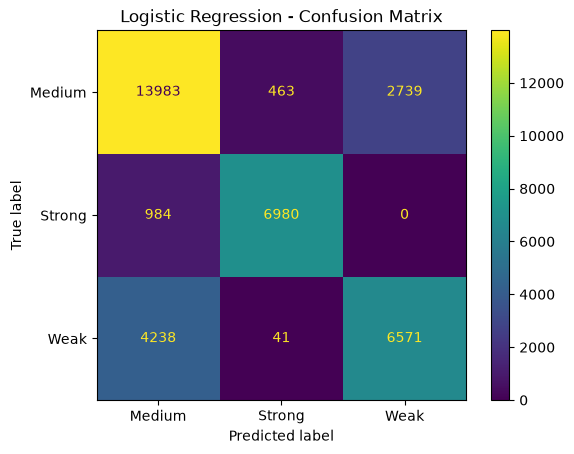

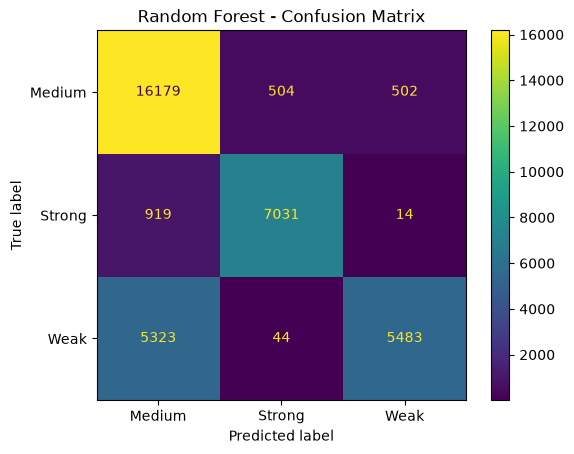

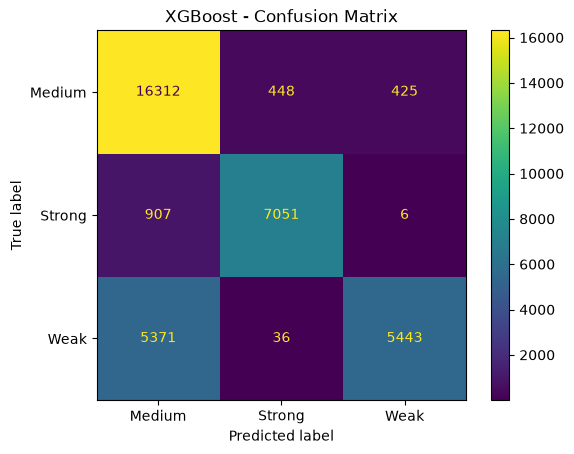

In [ ]:
# Confusion Matrix 

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)
plt.title("Random Forest - Confusion Matrix")
plt.show()

# XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [33]:
# Saving Models and Features List

import joblib

joblib.dump(
    xgb_model,
    '../models/xgboost_password_model.pkl'
)

joblib.dump(
    label_encoder,
    '../models/lable_encoder.pkl'
)

feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    '../models/feature_names.pkl'
)

['../models/feature_names.pkl']